# 02 - Decision Tree + Esperimento sulla scelta delle feature

**Obiettivo**: 
1. Addestrare un Decision Tree sul dataset PE-malware
2. Identificare le feature più importanti tramite `feature_importances_`
3. Confrontare 5 strategie di selezione delle feature

**Domanda di ricerca**: quante e quali feature servono davvero?

---

## 1. Import delle librerie

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 100
os.makedirs('../output', exist_ok=True)

print('Librerie caricate correttamente')

Librerie caricate correttamente


## 2. Caricamento e preparazione del dataset

Stessa procedura del notebook 01: rimuovo `Name` (identificativo) e `Malware` (target). Restano 77 feature.

In [2]:
df = pd.read_csv('../dataset/dataset_malwares.csv')

X = df.drop(columns=['Name', 'Malware'])
y = df['Malware']

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')

X shape: (19611, 77)
y shape: (19611,)


## 3. Split train/test

- `test_size=0.2`: 80% training, 20% test (convenzione standard)
- `random_state=0`: riproducibilità (stesso split tra notebook)
- `stratify=y`: mantiene le proporzioni 74,4%/25,6% in entrambi i set (importante con IR=2,9)

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0, stratify=y
)

print(f'Train: {X_train.shape[0]:,} campioni')
print(f'Test : {X_test.shape[0]:,} campioni')
print(f'\nProporzioni nel train:\n{y_train.value_counts(normalize=True).round(3)}')
print(f'\nProporzioni nel test:\n{y_test.value_counts(normalize=True).round(3)}')

Train: 15,688 campioni
Test : 3,923 campioni

Proporzioni nel train:
Malware
1    0.744
0    0.256
Name: proportion, dtype: float64

Proporzioni nel test:
Malware
1    0.744
0    0.256
Name: proportion, dtype: float64


## 4. Addestramento Decision Tree con TUTTE le 77 feature

Lo addestro per due motivi:
1. Mi serve come **baseline** (accuracy con tutte le feature)
2. Estraggo `feature_importances_` per identificare le top N

In [4]:
dt_full = DecisionTreeClassifier(random_state=0)
dt_full.fit(X_train, y_train)

y_pred_full = dt_full.predict(X_test)

acc_full  = accuracy_score (y_test, y_pred_full) * 100
prec_full = precision_score(y_test, y_pred_full) * 100
rec_full  = recall_score   (y_test, y_pred_full) * 100
f1_full   = f1_score       (y_test, y_pred_full) * 100

print(f'Decision Tree con tutte le 77 feature:')
print(f'   Accuracy : {acc_full:.2f}%')
print(f'   Precision: {prec_full:.2f}%')
print(f'   Recall   : {rec_full:.2f}%')
print(f'   F1-score : {f1_full:.2f}%')

Decision Tree con tutte le 77 feature:
   Accuracy : 98.57%
   Precision: 99.14%
   Recall   : 98.94%
   F1-score : 99.04%


## 5. Estrazione delle feature più importanti

Uso `feature_importances_`. La formula matematica è:

$$\text{importance}(j) = \sum_{\text{nodi che usano } j} \frac{N_{node}}{N_{total}} \cdot \Delta\text{Gini}$$

Dove $\Delta\text{Gini}$ = riduzione di impurità Gini causata dallo split. La somma di tutte le importanze fa 1.0.

In [5]:
imp_df = pd.DataFrame({
    'feature':    X.columns,
    'importance': dt_full.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

print('Top 15 feature secondo Decision Tree:')
print(imp_df.head(15).to_string(index=False))
print(f'\nSomma di tutte le importanze: {imp_df.importance.sum():.4f} (deve essere 1.0)')

Top 15 feature secondo Decision Tree:
                    feature  importance
      MajorSubsystemVersion    0.574062
                  Subsystem    0.149542
         MajorLinkerVersion    0.135047
              TimeDateStamp    0.057647
                   CheckSum    0.013282
MinorOperatingSystemVersion    0.007176
         SizeOfStackReserve    0.006271
ImageDirectoryEntrySecurity    0.006016
                  ImageBase    0.005930
         DllCharacteristics    0.005093
  SuspiciousImportFunctions    0.004982
       DirectoryEntryExport    0.002928
MajorOperatingSystemVersion    0.002795
            Characteristics    0.002311
      MinorSubsystemVersion    0.002031

Somma di tutte le importanze: 1.0000 (deve essere 1.0)


## 6. Grafico delle Top 15 feature

Salvato: ../output/feature_importance.png


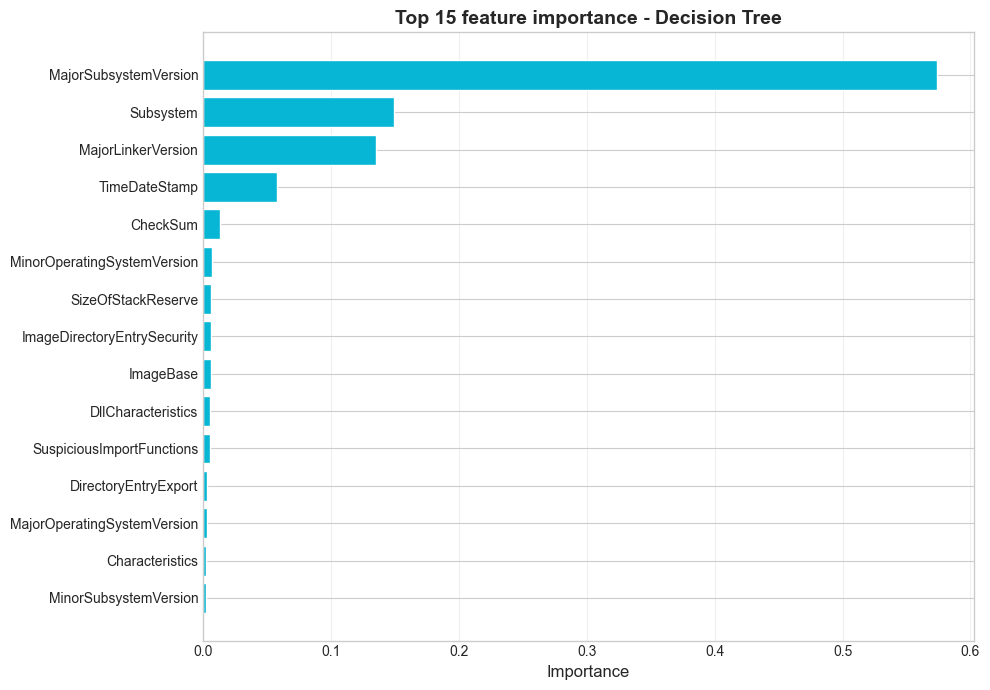

In [6]:
fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor('white')

top15 = imp_df.head(15).iloc[::-1]
ax.barh(top15['feature'], top15['importance'], color='#06B6D4',
        edgecolor='white', linewidth=1)

ax.set_xlabel('Importance', fontsize=12)
ax.set_title('Top 15 feature importance - Decision Tree', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('../output/feature_importance.png', dpi=150, bbox_inches='tight')
print('Salvato: ../output/feature_importance.png')
plt.show()

## 7. Estrazione Top 5 e Top 10

In [7]:
top5  = imp_df['feature'].head(5).tolist()
top10 = imp_df['feature'].head(10).tolist()

print('Top 5 feature:')
for i, f in enumerate(top5, 1):
    print(f'   {i}. {f}')

print('\nTop 10 feature:')
for i, f in enumerate(top10, 1):
    print(f'   {i}. {f}')

Top 5 feature:
   1. MajorSubsystemVersion
   2. Subsystem
   3. MajorLinkerVersion
   4. TimeDateStamp
   5. CheckSum

Top 10 feature:
   1. MajorSubsystemVersion
   2. Subsystem
   3. MajorLinkerVersion
   4. TimeDateStamp
   5. CheckSum
   6. MinorOperatingSystemVersion
   7. SizeOfStackReserve
   8. ImageDirectoryEntrySecurity
   9. ImageBase
   10. DllCharacteristics


## 8. Esperimento 1: confronto tra 5 strategie di selezione

Definisco 5 configurazioni e le confronto sul Decision Tree, mantenendo tutto il resto invariato (stesso split, stesso `random_state`).

| # | Strategia | N° feature | Note |
|---|-----------|------------|------|
| 1 | AddressOfEntryPoint + DllCharacteristics | 2 |
| 2 | SizeOfStackReserve + SectionMaxEntropy | 2 | Tecniche, entropia indica packing |
| 3 | Top 5 da feature_importances_ | 5 | Minimo indispensabile |
| 4 | Top 10 da feature_importances_ | 10 | Sweet spot |
| 5 | Tutte le feature | 77 | Benchmark superiore |

In [8]:
configs = {
    'Manuale 2 feat (prof)': ['AddressOfEntryPoint', 'DllCharacteristics'],
    'Manuale 2 feat tecnico': ['SizeOfStackReserve', 'SectionMaxEntropy'],
    'Top 5 (importances_)':  top5,
    'Top 10 (importances_)': top10,
    'Tutte le 77 feature':   list(X.columns),
}

results = []

for name, feats in configs.items():
    # Sottoinsieme delle feature
    X_train_sub = X_train[feats]
    X_test_sub  = X_test[feats]
    
    # Addestra Decision Tree
    clf = DecisionTreeClassifier(random_state=0)
    clf.fit(X_train_sub, y_train)
    pred = clf.predict(X_test_sub)
    
    # Calcola metriche
    acc  = accuracy_score (y_test, pred) * 100
    prec = precision_score(y_test, pred) * 100
    rec  = recall_score   (y_test, pred) * 100
    f1   = f1_score       (y_test, pred) * 100
    
    results.append({
        'Strategia': name,
        'N feat': len(feats),
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-score': f1
    })
    print(f'{name:30s} (n={len(feats):2d}) -> Acc={acc:.2f}, Prec={prec:.2f}, Rec={rec:.2f}, F1={f1:.2f}')

results_df = pd.DataFrame(results).round(2)
print('\n')
print('=' * 90)
print('  TABELLA RIEPILOGATIVA DEI RISULTATI')
print('=' * 90)
print(results_df.to_string(index=False))

Manuale 2 feat (prof)          (n= 2) -> Acc=94.16, Prec=96.16, Rec=95.99, F1=96.08
Manuale 2 feat tecnico         (n= 2) -> Acc=89.60, Prec=90.03, Rec=96.75, F1=93.27
Top 5 (importances_)           (n= 5) -> Acc=98.47, Prec=98.97, Rec=98.97, F1=98.97
Top 10 (importances_)          (n=10) -> Acc=98.65, Prec=98.94, Rec=99.25, F1=99.09
Tutte le 77 feature            (n=77) -> Acc=98.57, Prec=99.14, Rec=98.94, F1=99.04


  TABELLA RIEPILOGATIVA DEI RISULTATI
             Strategia  N feat  Accuracy  Precision  Recall  F1-score
 Manuale 2 feat (prof)       2     94.16      96.16   95.99     96.08
Manuale 2 feat tecnico       2     89.60      90.03   96.75     93.27
  Top 5 (importances_)       5     98.47      98.97   98.97     98.97
 Top 10 (importances_)      10     98.65      98.94   99.25     99.09
   Tutte le 77 feature      77     98.57      99.14   98.94     99.04


## 9. Grafico comparativo delle strategie

Salvato: ../output/feature_strategies_comparison.png


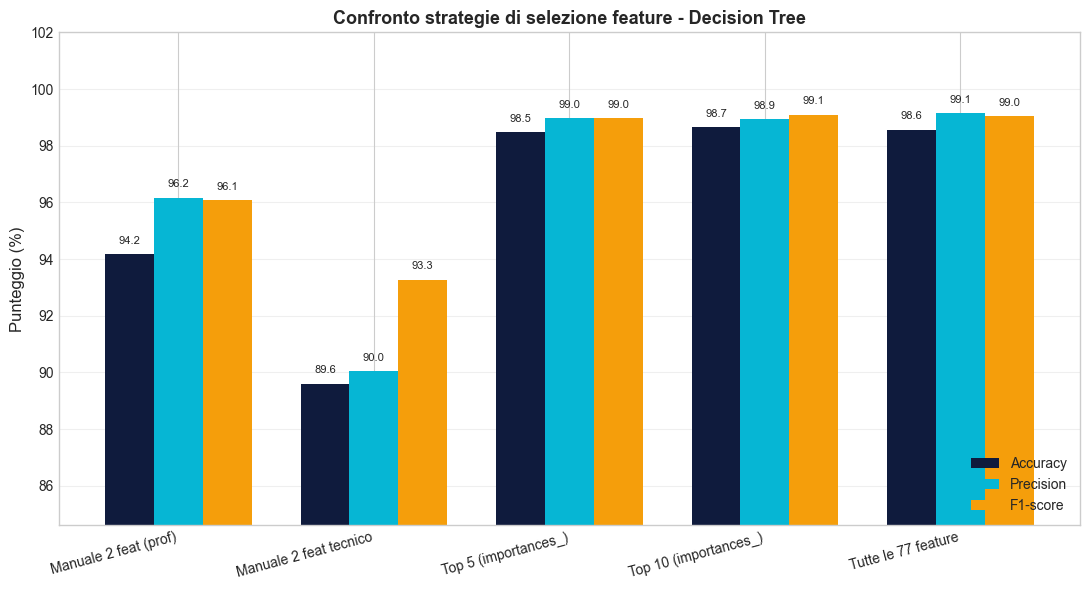

In [9]:
fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor('white')

x = np.arange(len(results_df))
width = 0.25

bars1 = ax.bar(x - width, results_df['Accuracy'],  width, label='Accuracy',  color='#0F1B3D')
bars2 = ax.bar(x,         results_df['Precision'], width, label='Precision', color='#06B6D4')
bars3 = ax.bar(x + width, results_df['F1-score'],  width, label='F1-score',  color='#F59E0B')

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.3,
                f'{h:.1f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(results_df['Strategia'], rotation=15, ha='right', fontsize=10)
ax.set_ylabel('Punteggio (%)', fontsize=12)
ax.set_title('Confronto strategie di selezione feature - Decision Tree',
             fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
ax.set_ylim(min(results_df['F1-score'].min(), results_df['Accuracy'].min()) - 5, 102)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../output/feature_strategies_comparison.png', dpi=150, bbox_inches='tight')
print('Salvato: ../output/feature_strategies_comparison.png')
plt.show()

## 10. Matrice di confusione del Decision Tree con tutte le 77 feature

Calcolo la confusion matrix come riferimento (utile per il confronto con Random Forest nel prossimo notebook).

Decision Tree - Matrice di confusione:
   TP (malware corretti) = 2,889
   FN (malware sfuggiti) = 31
   FP (falsi allarmi)    = 25
   TN (legit corretti)   = 978

Salvato: ../output/confusion_matrix_dt.png


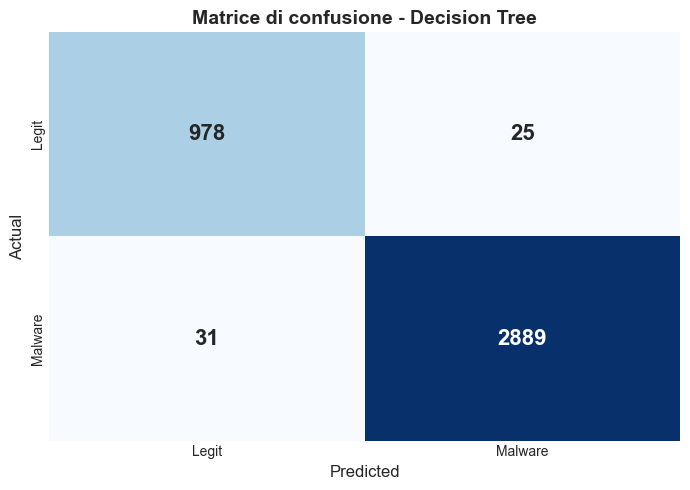

In [10]:
cm = confusion_matrix(y_test, y_pred_full)
TN, FP, FN, TP = cm.ravel()

print(f'Decision Tree - Matrice di confusione:')
print(f'   TP (malware corretti) = {TP:,}')
print(f'   FN (malware sfuggiti) = {FN:,}')
print(f'   FP (falsi allarmi)    = {FP:,}')
print(f'   TN (legit corretti)   = {TN:,}')

fig, ax = plt.subplots(figsize=(7, 5))
fig.patch.set_facecolor('white')
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Legit', 'Malware'],
            yticklabels=['Legit', 'Malware'],
            annot_kws={'size': 16, 'weight': 'bold'})
ax.set_title('Matrice di confusione - Decision Tree', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
plt.tight_layout()
plt.savefig('../output/confusion_matrix_dt.png', dpi=150, bbox_inches='tight')
print('\nSalvato: ../output/confusion_matrix_dt.png')
plt.show()

## 11. Riepilogo

In [11]:
print('=' * 70)
print('RIEPILOGO FINALE')
print('=' * 70)
print('\nTabella confronto strategie:')
print(results_df[['Strategia', 'Accuracy', 'Precision', 'F1-score']].to_string(index=False))
print('\nDecision Tree con tutte le 77 feature:')
print(f'   TP={TP}, FN={FN}, FP={FP}, TN={TN}')
print(f'   Accuracy={acc_full:.2f}%, Precision={prec_full:.2f}%, Recall={rec_full:.2f}%, F1={f1_full:.2f}%')

RIEPILOGO FINALE

Tabella confronto strategie:
             Strategia  Accuracy  Precision  F1-score
 Manuale 2 feat (prof)     94.16      96.16     96.08
Manuale 2 feat tecnico     89.60      90.03     93.27
  Top 5 (importances_)     98.47      98.97     98.97
 Top 10 (importances_)     98.65      98.94     99.09
   Tutte le 77 feature     98.57      99.14     99.04

Decision Tree con tutte le 77 feature:
   TP=2889, FN=31, FP=25, TN=978
   Accuracy=98.57%, Precision=99.14%, Recall=98.94%, F1=99.04%


## 12. Analisi di approfondimento (post-studio): perché MajorSubsystemVersion domina?

Questa sezione è stata aggiunta **dopo lo studio del modello**, per indagare un risultato emerso dalla `feature_importances_`: la feature `MajorSubsystemVersion` da sola pesa circa il 57% delle decisioni del Decision Tree.

Verifico empiricamente la sua distribuzione per classe con una tabella incrociata e un grafico. L'ipotesi è che la feature agisca come *proxy dell'epoca di compilazione* del file: i malware del dataset sono in larga parte storici (targettano Windows vecchi, versioni 4 e 5), mentre i file legittimi sono più moderni (versioni 6 e 10).

In [ ]:
feat = 'MajorSubsystemVersion'

ct = pd.crosstab(df[feat], df['Malware'])
ct.columns = ['Legit', 'Malware']
tot = ct['Legit'] + ct['Malware']
ct['%Malware'] = (ct['Malware'] / tot * 100).round(1)
print('Distribuzione di MajorSubsystemVersion per classe:')
print(ct.to_string())

print(f"\nMedia legit:   {df[df['Malware']==0][feat].mean():.2f}")
print(f"Media malware: {df[df['Malware']==1][feat].mean():.2f}")

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('white')

x = np.arange(len(ct.index))
width = 0.38
ax.bar(x - width/2, ct['Legit'],   width, label='Legit (0)',   color='#16A34A', edgecolor='white')
ax.bar(x + width/2, ct['Malware'], width, label='Malware (1)', color='#DC2626', edgecolor='white')

ax.set_xlabel('MajorSubsystemVersion (versione Windows target)', fontsize=12)
ax.set_ylabel('Numero di campioni', fontsize=12)
ax.set_title('Distribuzione di MajorSubsystemVersion per classe', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f'v{int(v)}' for v in ct.index])
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../output/majorsubsystem_analysis.png', dpi=150, bbox_inches='tight')
print('\nSalvato: ../output/majorsubsystem_analysis.png')
plt.show()